In [1]:
from sklearn.linear_model import LinearRegression
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

In [2]:

path = r"C:\toolbox-amiris-emlab\emlabpy\plots\Scenarios\transition3-EOM"
high = pd.DataFrame()
low = pd.DataFrame()

# path_to_plots = os.path.join(os.getcwd(),  "Scenarios", "AMIRIS_Results", scenario )
# if not os.path.exists(path_to_plots):
#     os.makedirs(path_to_plots)
years_to_generate = list(range(2020,2051))
for year in years_to_generate:    
    path_to_results = os.path.join(path + "\\" + str(year) + ".xlsx")
    elec_prices_data =  pd.read_excel(path_to_results, sheet_name='energy_exchange', index_col=0)  
    high.at[:, year] = elec_prices_data["ElectricityPriceInEURperMWH"]
    
path = r"C:\toolbox-amiris-emlab\emlabpy\plots\Scenarios\transition3-EOM_lowH2"    
for year in years_to_generate:    
    path_to_results = os.path.join(path + "\\" + str(year) + ".xlsx")
    elec_prices_data =  pd.read_excel(path_to_results, sheet_name='energy_exchange', index_col=0)  
    low.at[:, year] = elec_prices_data["ElectricityPriceInEURperMWH"]    

In [4]:
high = high[(high < 350)]
low = low[(low < 350)]

In [8]:
high['scenario'] = 'EOM'
low['scenario'] = 'EOM_lowH2'
combined_data = pd.concat([high, low], ignore_index=False) 

In [23]:
melted_data

,scenario,Year,Value
0,EOM,2020,3.269549
1,EOM,2020,3.269549
2,EOM,2020,3.272818
3,EOM,2020,3.272818
4,EOM,2020,8.328571
...,...,...,...
543115,EOM_lowH2,2050,80.840163
543116,EOM_lowH2,2050,58.786866
543117,EOM_lowH2,2050,58.791174
543118,EOM_lowH2,2050,24.188461


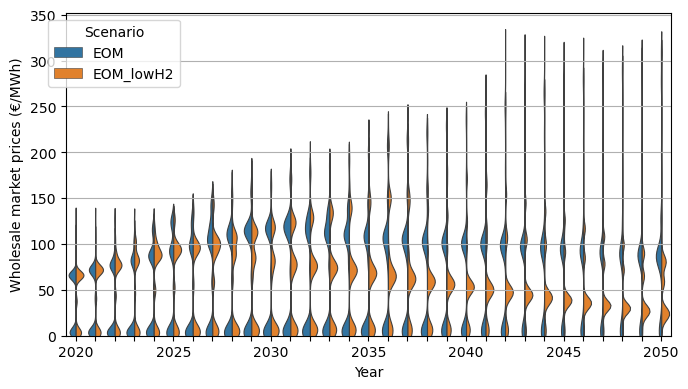

In [27]:
melted_data = pd.melt(
    combined_data,
    id_vars=['scenario'],
    var_name='Year',
    value_name='Value'
)

# Filter out unnecessary columns like "Unnamed"
# melted_data = melted_data[~melted_data['Year'].str.contains('Unnamed')]

# Convert years to numeric for proper ordering
melted_data['Year'] = pd.to_numeric(melted_data['Year'], errors='coerce')

# Create the violin plot
ax = plt.figure(figsize=(7, 4))
sns.violinplot(
    x='Year',
    y='Value',
    hue='scenario',
    data=melted_data,
    split=True,
#     scale='width', 
    density_norm="count", 
    linewidth=0.8, 
    inner=None
    
)
# plt.title('Violin Plot of High and Low Scenarios (2020-2050)', fontsize=16)
plt.xlabel('Year',fontsize='medium')
plt.ylabel('Wholesale market prices (€/MWh)', fontsize='medium')
plt.grid(True, which='major', axis='y')#, linestyle='--', linewidth=0.5, color='gray')
plt.xticks( fontsize='medium')
# years = filtered_df.columns.astype(int)
plt.xticks(ticks=range(len(years_to_generate)), labels=[str(year) if year % 5 == 0 else '' for year in years_to_generate])
plt.legend(title='Scenario', loc='upper right', bbox_to_anchor=(0.2 , 1), )
plt.tight_layout()
plt.ylim(0, None) 
plt.show()
# fig10 = plt.get_figure()
ax.savefig("Hourly Electricity prices violin.png")